In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression

import lightgbm as lgb
from lightgbm import LGBMClassifier

df = pd.read_parquet('../data/loans_clean.parquet')

df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df["credit_history_months"] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df["annual_inc"].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

df_train = df[df['issue_year'].isin([2014, 2015])].copy()
df_val   = df[df["issue_year"] == 2016].copy()
df_test  = df[df['issue_year'] == 2017].copy()

y_train = df_train['default'].values
y_val   = df_val['default'].values


print(f"LightGBM: {lgb.__version__}")

LightGBM: 4.6.0


In [2]:
gain_rate = 0.10
loss_rate = 0.50

def calculate_profit(df_subset, approval_mask, gain_rate=gain_rate, loss_rate=loss_rate):
    approved = df_subset[approval_mask]
    if len(approved) == 0:
        return 0
    profit = np.where(
        approved["default"] == 0,
         gain_rate * approved["loan_amnt"],
        -loss_rate * approved["loan_amnt"]
    )
    return profit.sum()


In [3]:
df_train_fe = df_train.copy()
df_val_fe = df_val.copy()
df_test_fe = df_test.copy()

def prep_features(df):
    """Apply feature engineering decisions from EDA."""
    df = df.copy()
    
    redundant = [
        "fico_range_high",
        "funded_amnt",
        "funded_amnt_inv",
        "num_sats",
        "installment",
        "num_rev_tl_bal_gt_0",
    ]

    joint_cols = [c for c in df.columns if c.startswith("sec_app") or c.endswith("_joint")]

    high_cardinality = ["zip_code", "sub_grade"]

    split_cols = ["issue_year"]

    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
        "5 years": 5, "6 years": 6, '7 years': 7, "8 years": 8, "9 years": 9,
        "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
    
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    
    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns]
    )
    
    return df



df_train_fe = prep_features(df_train_fe)
df_val_fe = prep_features(df_val_fe)
df_test_fe = prep_features(df_test_fe)

print(f"Features after prep: {df_train_fe.shape[1]}")
print(f"\nTrain shape: {df_train_fe.shape}")
print(f"Val shape:   {df_val_fe.shape}")

Features after prep: 80

Train shape: (598647, 80)
Val shape:   (293095, 80)


In [4]:
y_train = df_train_fe["default"].values
y_val = df_val_fe["default"].values

x_train = df_train_fe.drop(columns=["default"])
x_val = df_val_fe.drop(columns=['default'])

x_train['term'] = x_train['term'].str.extract(r'(\d+)').astype(int)
x_val['term']   = x_val['term'].str.extract(r'(\d+)').astype(int)


In [5]:
import joblib

lgbm = joblib.load("../models/lgbm_tuned.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")

x_train_proc = preprocessor.transform(x_train)
x_val_proc   = preprocessor.transform(x_val)

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs", random_state=42)
logreg.fit(x_train_proc, y_train)
logreg_probs = logreg.predict_proba(x_val_proc)[:, 1]

lgbm_probs = lgbm.predict_proba(x_val_proc)[:, 1]
print("LightGBM tuned")
print(f"  AUC: {roc_auc_score(y_val, lgbm_probs):.4f}")
print(f"  Brier: {brier_score_loss(y_val, lgbm_probs):.4f}")
print(f"  Iterations: {lgbm.best_iteration_}")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM tuned
  AUC: 0.7280
  Brier: 0.1578
  Iterations: 1000


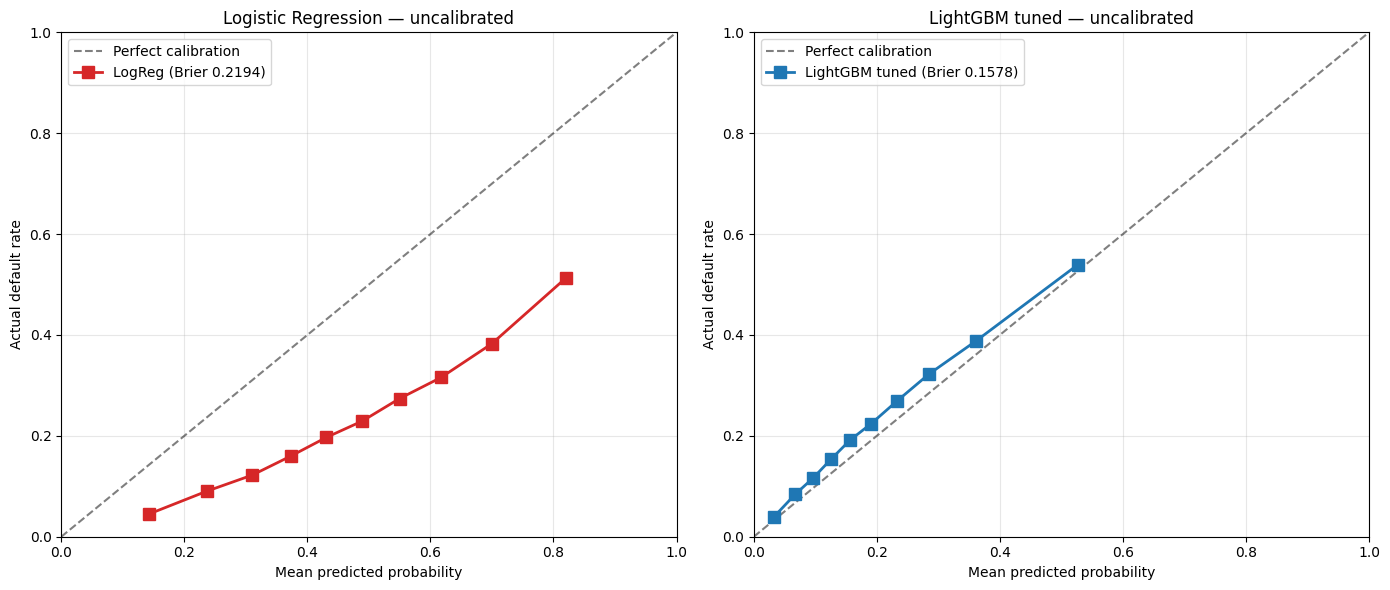

In [6]:
prob_true_lr, prob_pred_lr = calibration_curve(y_val,logreg_probs, n_bins=10, strategy='quantile')
prob_true_lgbm, prob_pred_lgbm = calibration_curve(y_val, lgbm_probs, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1,2 ,figsize =(14,6))

# logreg
ax = axes[0]
ax.plot([0,1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred_lr, prob_true_lr, 's-', color='#d62728', linewidth=2, markersize=8,
        label=f'LogReg (Brier {brier_score_loss(y_val, logreg_probs):.4f})')

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual default rate')
ax.set_title('Logistic Regression — uncalibrated')

ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# lightGBM
ax = axes[1]
ax.plot([0,1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred_lgbm, prob_true_lgbm, 's-', color='#1f77b4', linewidth=2, markersize=8,
        label=f'LightGBM tuned (Brier {brier_score_loss(y_val, lgbm_probs):.4f})')

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual default rate')
ax.set_title('LightGBM tuned — uncalibrated')

ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../reports/figures/calibration_before.png", dpi=120, bbox_inches='tight')
plt.show()

In [7]:
np.random.seed(42)

val_size = x_val_proc.shape[0]
calib_idx = np.random.choice(val_size, size=val_size//2, replace=False)
eval_idx = np.setdiff1d(np.arange(val_size), calib_idx)

x_val_calib = x_val_proc[calib_idx]
y_val_calib = y_val[calib_idx]
x_val_eval  = x_val_proc[eval_idx]
y_val_eval  = y_val[eval_idx]

print(f"Calibration set: {len(calib_idx):,} samples")
print(f"Evaluation set:  {len(eval_idx):,} samples")

logreg_probs_calib = logreg.predict_proba(x_val_calib)[:, 1]
logreg_probs_eval = logreg.predict_proba(x_val_eval)[:, 1]
lgbm_probs_calib = lgbm.predict_proba(x_val_calib)[:, 1]
lgbm_probs_eval = lgbm.predict_proba(x_val_eval)[:, 1]


iso_logreg = IsotonicRegression(out_of_bounds='clip')
iso_logreg.fit(logreg_probs_calib, y_val_calib)

iso_lgbm =IsotonicRegression(out_of_bounds='clip')
iso_lgbm.fit(lgbm_probs_calib, y_val_calib)

logreg_cal_eval = iso_logreg.predict(logreg_probs_eval)
lgbm_cal_eval = iso_lgbm.predict(lgbm_probs_eval)

logreg_uncal_eval = logreg_probs_eval
lgbm_uncal_eval   = lgbm_probs_eval

print("\n=== CALIBRATION RESULTS (evaluated on held-out half of val) ===\n")
print("LogReg:")
print(f"  Before  AUC: {roc_auc_score(y_val_eval, logreg_uncal_eval):.4f}  Brier: {brier_score_loss(y_val_eval, logreg_uncal_eval):.4f}")
print(f"  After   AUC: {roc_auc_score(y_val_eval, logreg_cal_eval):.4f}  Brier: {brier_score_loss(y_val_eval, logreg_cal_eval):.4f}")
brier_lr_before = brier_score_loss(y_val_eval, logreg_uncal_eval)
brier_lr_after = brier_score_loss(y_val_eval, logreg_cal_eval)
print(f"  Brier improvement: {(brier_lr_before - brier_lr_after) / brier_lr_before * 100:.1f}%")

print("\nLightGBM tuned:")
print(f"  Before  AUC: {roc_auc_score(y_val_eval, lgbm_uncal_eval):.4f}  Brier: {brier_score_loss(y_val_eval, lgbm_uncal_eval):.4f}")
print(f"  After   AUC: {roc_auc_score(y_val_eval, lgbm_cal_eval):.4f}  Brier: {brier_score_loss(y_val_eval, lgbm_cal_eval):.4f}")
brier_lg_before = brier_score_loss(y_val_eval, lgbm_uncal_eval)
brier_lg_after = brier_score_loss(y_val_eval, lgbm_cal_eval)
print(f"  Brier improvement: {(brier_lg_before - brier_lg_after) / brier_lg_before * 100:.1f}%")

Calibration set: 146,547 samples
Evaluation set:  146,548 samples


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== CALIBRATION RESULTS (evaluated on held-out half of val) ===

LogReg:
  Before  AUC: 0.7173  Brier: 0.2189
  After   AUC: 0.7172  Brier: 0.1599
  Brier improvement: 27.0%

LightGBM tuned:
  Before  AUC: 0.7300  Brier: 0.1580
  After   AUC: 0.7298  Brier: 0.1572
  Brier improvement: 0.5%


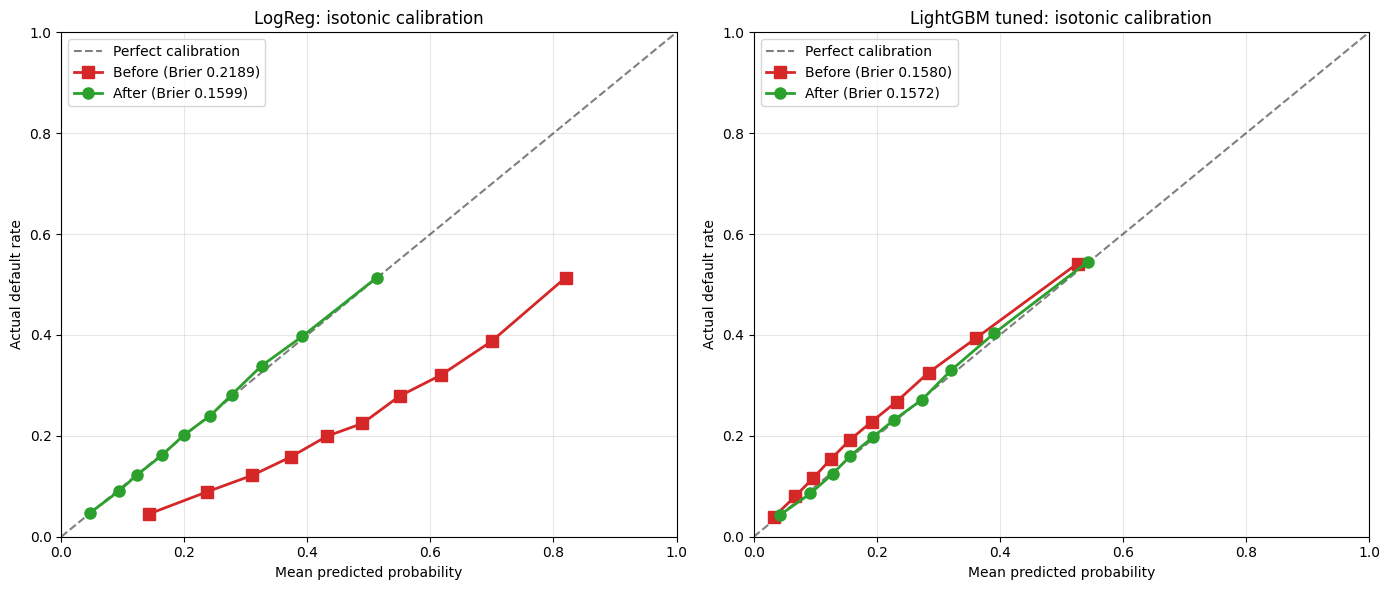

In [8]:
prob_true_lr_b, prob_pred_lr_b = calibration_curve(y_val_eval, logreg_uncal_eval, n_bins=10, strategy='quantile')
prob_true_lr_a, prob_pred_lr_a = calibration_curve(y_val_eval, logreg_cal_eval, n_bins=10, strategy='quantile')
prob_true_lg_b, prob_pred_lg_b = calibration_curve(y_val_eval, lgbm_uncal_eval, n_bins=10, strategy='quantile')
prob_true_lg_a, prob_pred_lg_a = calibration_curve(y_val_eval, lgbm_cal_eval, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logreg before/after
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Perfect calibration")
ax.plot(prob_pred_lr_b, prob_true_lr_b, 's-', color='#d62728', linewidth=2, markersize=8,
        label=f'Before (Brier {brier_score_loss(y_val_eval, logreg_uncal_eval):.4f})')
ax.plot(prob_pred_lr_a, prob_true_lr_a,'o-', color='#2ca02c', linewidth=2, markersize=8,
        label=f'After (Brier {brier_score_loss(y_val_eval, logreg_cal_eval):.4f})')

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual default rate")
ax.set_title("LogReg: isotonic calibration")

ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

#LightGBM before/after
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred_lg_b, prob_true_lg_b, 's-', color='#d62728', linewidth=2, markersize=8,
        label=f'Before (Brier {brier_score_loss(y_val_eval, lgbm_uncal_eval):.4f})')
ax.plot(prob_pred_lg_a, prob_true_lg_a, 'o-', color='#2ca02c', linewidth=2, markersize=8,
        label=f'After (Brier {brier_score_loss(y_val_eval, lgbm_cal_eval):.4f})')
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual default rate")
ax.set_title("LightGBM tuned: isotonic calibration")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/figures/calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Optimal threshold:   0.1592
Optimal profit:      $33,321,825
Break-even (theory): 0.1667


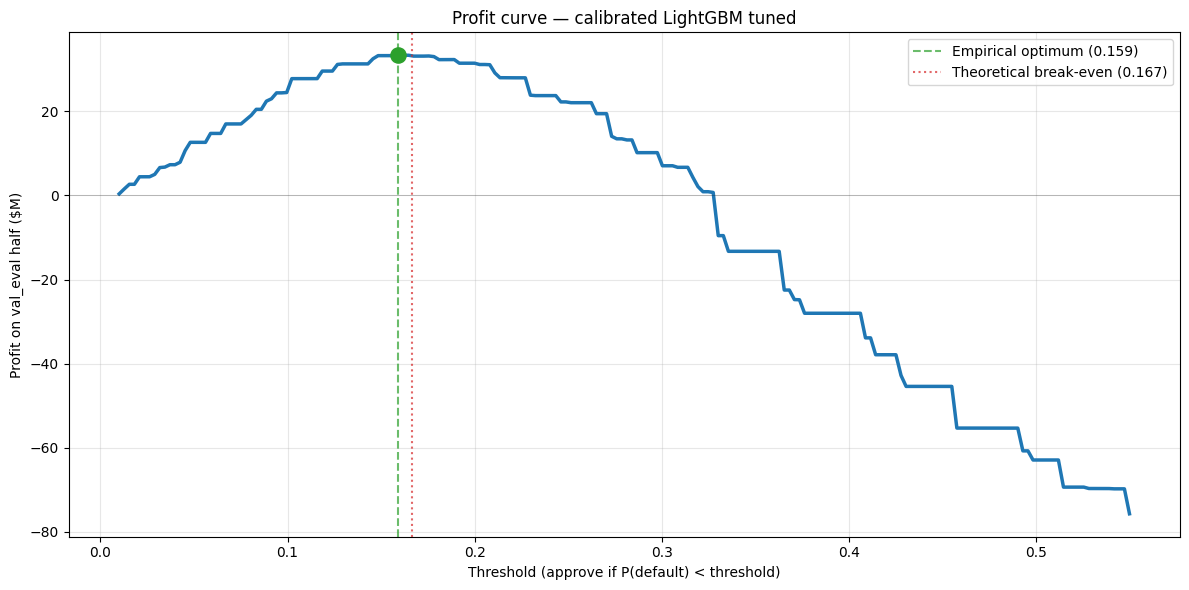

In [9]:
df_val_eval = df_val.iloc[eval_idx].reset_index(drop=True)

thresholds_full = np.linspace(0.01, 0.55, 200)
profits_full = np.array([calculate_profit(df_val_eval, lgbm_cal_eval < t) for t in thresholds_full])


best_idx = int(np.argmax(profits_full))
best_threshold = thresholds_full[best_idx]
best_profit = profits_full[best_idx]

# theoretical break-even (where expected profit per loan = 0)
break_even = gain_rate / (gain_rate + loss_rate)

print(f"Optimal threshold:   {best_threshold:.4f}")
print(f"Optimal profit:      ${best_profit:,.0f}")
print(f"Break-even (theory): {break_even:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds_full, profits_full/1e6, color='#1f77b4', linewidth=2.5)
ax.axvline(best_threshold, color='#2ca02c', linestyle='--', alpha=0.7,
           label=f'Empirical optimum ({best_threshold:.3f})')
ax.axvline(break_even, color='#d62728', linestyle=':', alpha=0.7,
           label=f'Theoretical break-even ({break_even:.3f})')
ax.axhline(0, color='black', alpha=0.3, linewidth=0.5)
ax.scatter([best_threshold], [best_profit/1e6], color='#2ca02c', s=120, zorder=5)

ax.set_xlabel("Threshold (approve if P(default) < threshold)")
ax.set_ylabel("Profit on val_eval half ($M)")
ax.set_title("Profit curve — calibrated LightGBM tuned")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/profit_curve.png', dpi=120, bbox_inches='tight')
plt.show()

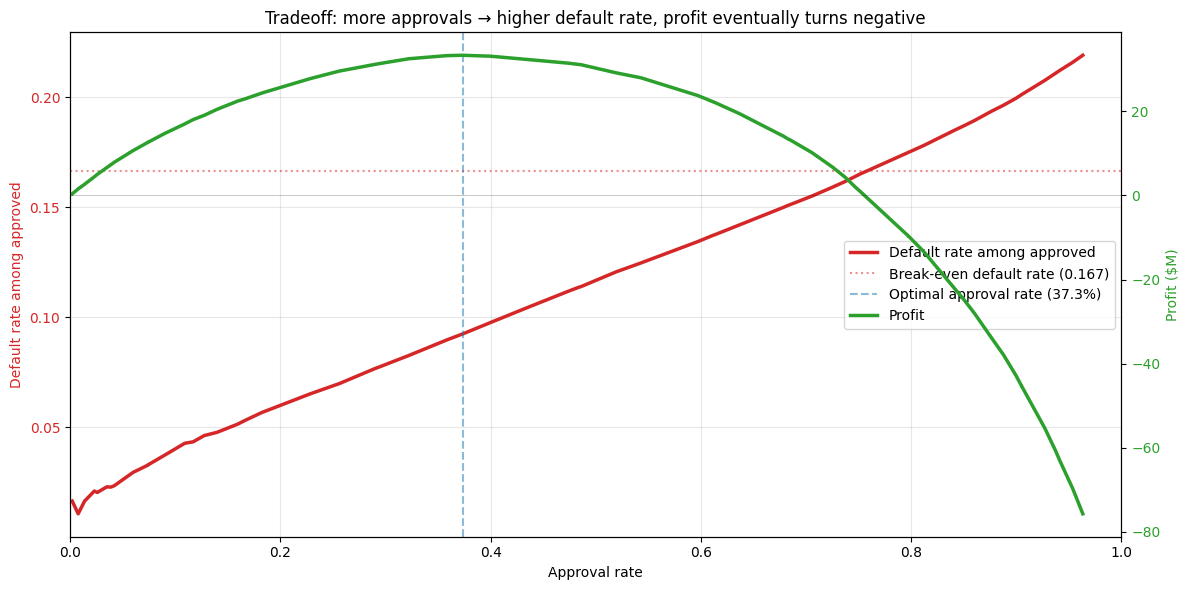

In [10]:
approval_rates = []
default_rates_approved = []
profits_at_rate = []

for t in thresholds_full:
    approval_mask = lgbm_cal_eval <t
    if approval_mask.sum() > 0 :
        approval_rates.append(approval_mask.mean())
        default_rates_approved.append(df_val_eval[approval_mask]['default'].mean())
        profits_at_rate.append(calculate_profit(df_val_eval, approval_mask))
    else:
        approval_rates.append(0)
        default_rates_approved.append(0)
        profits_at_rate.append(0)

approval_rates = np.array(approval_rates)
default_rates_approved = np.array(default_rates_approved)
profits_at_rate = np.array(profits_at_rate)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(approval_rates, default_rates_approved, color='#d62728', linewidth=2.5,
         label="Default rate among approved")
ax1.axhline(break_even, color="#d62728", linestyle=':', alpha=0.5,
            label=f'Break-even default rate ({break_even:.3f})')

ax1.set_xlabel("Approval rate")
ax1.set_ylabel("Default rate among approved", color ="#d62728")

ax1.tick_params(axis='y', labelcolor="#d62728")
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 1)

ax2 = ax1.twinx()

ax2.set_ylabel('Profit ($M)', color="#2ca02c")
ax2.plot(approval_rates, profits_at_rate/1e6, color ='#2ca02c', linewidth=2.5, label='Profit')
ax2.axhline(0, color='black', alpha=0.3, linewidth=0.5)
ax2.tick_params(axis='y', labelcolor='#2ca02c')

opt_approval_rate = (lgbm_cal_eval < best_threshold).mean()
ax1.axvline(opt_approval_rate, color='#1f77b4', linestyle='--', alpha=0.5,
            label=f'Optimal approval rate ({opt_approval_rate:.1%})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Tradeoff: more approvals → higher default rate, profit eventually turns negative')
plt.tight_layout()
plt.savefig('../reports/figures/approval_default_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

Computing sensitivity matrix...


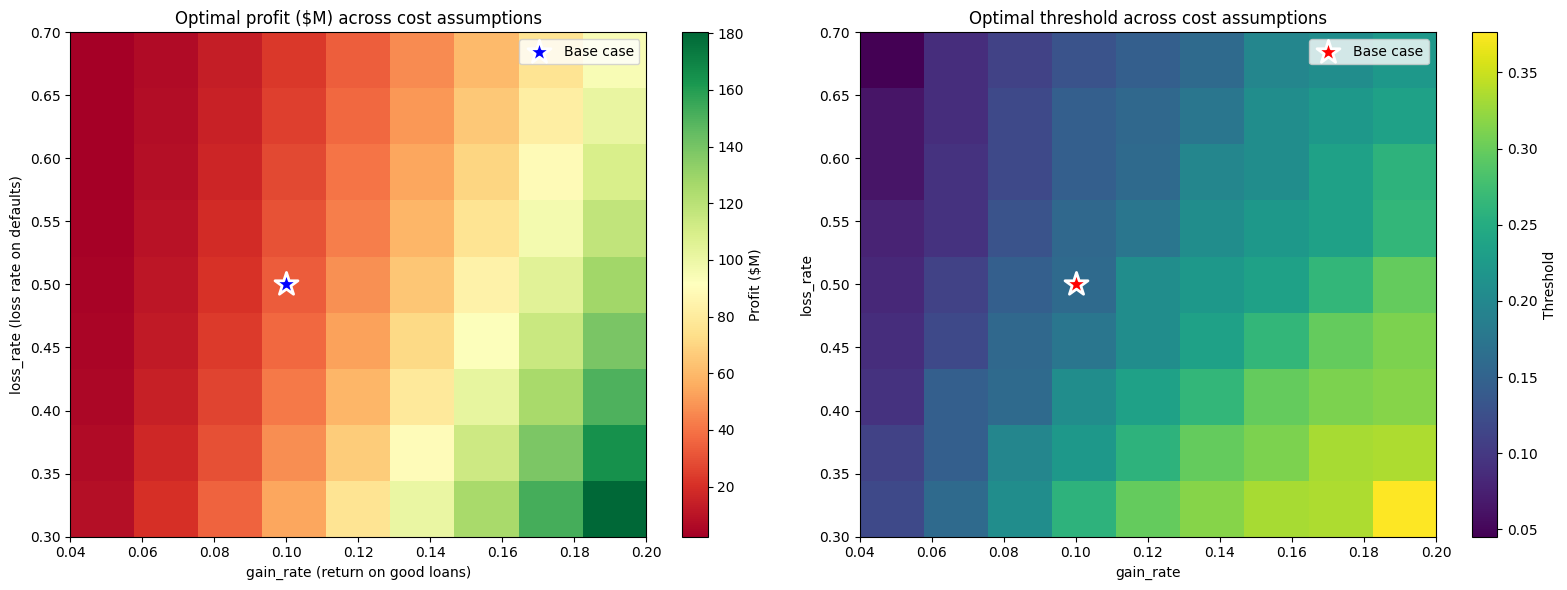


=== SENSITIVITY ANALYSIS ===
Base case (gain=0.100, loss=0.500): $33.3M
Best case in sweep: $180.3M
Worst case in sweep: $2.4M

Threshold range across sweep: [0.045, 0.376]


In [11]:
gain_rates = np.linspace(0.04, 0.20, 9) 
loss_rates = np.linspace(0.30, 0.70, 9)

opt_profit_matrix = np.zeros((len(loss_rates), len(gain_rates)))
opt_threshold_matrix = np.zeros((len(loss_rates), len(gain_rates)))

print("Computing sensitivity matrix...")
for i, lr in enumerate(loss_rates):
    for j, gr in enumerate(gain_rates):
        profits = np.array([calculate_profit(df_val_eval, lgbm_cal_eval < t, gain_rate=gr, loss_rate=lr)
                            for t in thresholds_full])
        opt_idx = int(np.argmax(profits))
        opt_profit_matrix[i, j] = profits[opt_idx]
        opt_threshold_matrix[i, j] = thresholds_full[opt_idx]


# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.imshow(opt_profit_matrix/1e6, cmap='RdYlGn', aspect='auto', origin='lower',
               extent=[gain_rates[0], gain_rates[-1], loss_rates[0], loss_rates[-1]])

ax.set_xlabel("gain_rate (return on good loans)")
ax.set_ylabel("loss_rate (loss rate on defaults)")
ax.set_title("Optimal profit ($M) across cost assumptions")

ax.scatter([gain_rate], [loss_rate], color='blue', s=300, marker='*', zorder=5,
           edgecolors='white', linewidth=2, label='Base case')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Profit ($M)')

ax = axes[1]
im = ax.imshow(opt_threshold_matrix, cmap='viridis', aspect='auto', origin='lower',
               extent=[gain_rates[0], gain_rates[-1], loss_rates[0], loss_rates[-1]])
ax.set_xlabel("gain_rate")
ax.set_ylabel("loss_rate")
ax.set_title("Optimal threshold across cost assumptions")

ax.scatter([gain_rate], [loss_rate], color='red', s=300, marker='*', zorder=5,
           edgecolors='white', linewidth=2, label='Base case')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Threshold')

plt.tight_layout()
plt.savefig('../reports/figures/cost_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

gain_idx = int(np.argmin(np.abs(gain_rates - gain_rate)))
loss_idx = int(np.argmin(np.abs(loss_rates - loss_rate)))

print(f"\n=== SENSITIVITY ANALYSIS ===")
print(f"Base case (gain={gain_rates[gain_idx]:.3f}, loss={loss_rates[loss_idx]:.3f}): "
      f"${opt_profit_matrix[loss_idx, gain_idx]/1e6:.1f}M")
print(f"Best case in sweep: ${opt_profit_matrix.max()/1e6:.1f}M")
print(f"Worst case in sweep: ${opt_profit_matrix.min()/1e6:.1f}M")
print(f"\nThreshold range across sweep: [{opt_threshold_matrix.min():.3f}, {opt_threshold_matrix.max():.3f}]")

In [12]:
import joblib
from pathlib import Path

Path('../models').mkdir(parents=True, exist_ok=True)

champion_artifact = {
    'preprocessor': preprocessor,
    'base_model': lgbm,
    'calibrator': iso_lgbm,
    'best_threshold': float(best_threshold),
    'best_params': lgbm.get_params(),
    'val_metrics': {
        'auc_uncalibrated': float(roc_auc_score(y_val_eval, lgbm_uncal_eval)),
        'auc_calibrated':   float(roc_auc_score(y_val_eval, lgbm_cal_eval)),
        'brier_uncalibrated': float(brier_score_loss(y_val_eval, lgbm_uncal_eval)),
        'brier_calibrated':   float(brier_score_loss(y_val_eval, lgbm_cal_eval)),
        'optimal_threshold': float(best_threshold),
        'optimal_profit_val_eval': float(best_profit),
    }
}

joblib.dump(champion_artifact, "../models/champion_lgbm.pkl")

print("Champion model saved to models/champion_lgbm.pkl")
print(f"Size: {Path('../models/champion_lgbm.pkl').stat().st_size / 1e6:.1f} MB")

Champion model saved to models/champion_lgbm.pkl
Size: 10.2 MB
